In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import collections
from mlxtend.preprocessing.transactionencoder import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

In [9]:
df  = pd.read_csv("grocery.csv")

In [8]:
df.head()

,Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,Item 10
0,pork,bottled water,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,domestic eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fruit/vegetable juice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,frozen vegetables,hamburger meat,fruit/vegetable juice,chicken,other vegetables,NaN,NaN,NaN,NaN,NaN
4,detergent,pip fruit,whipped/sour cream,soda,cream cheese,domestic eggs,bottled water,pork,tropical fruit,fruit/vegetable juice


In [11]:
df.shape

(9500, 10)

In [12]:
df.describe()

,Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,Item 10
count,9500,8527,7636,6723,5690,4739,3808,2868,1937,955
unique,30,30,30,30,30,30,30,30,30,30
top,pip fruit,frozen vegetables,hamburger meat,rolls/buns,ice cream,fruit/vegetable juice,rolls/buns,brown bread,root vegetables,brown bread
freq,348,323,299,246,222,176,152,116,85,45


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9500 entries, 0 to 9499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Item 1   9500 non-null   str  
 1   Item 2   8527 non-null   str  
 2   Item 3   7636 non-null   str  
 3   Item 4   6723 non-null   str  
 4   Item 5   5690 non-null   str  
 5   Item 6   4739 non-null   str  
 6   Item 7   3808 non-null   str  
 7   Item 8   2868 non-null   str  
 8   Item 9   1937 non-null   str  
 9   Item 10  955 non-null    str  
dtypes: str(10)
memory usage: 1.3 MB


In [14]:
df.isnull().sum()

Item 1        0
Item 2      973
Item 3     1864
Item 4     2777
Item 5     3810
Item 6     4761
Item 7     5692
Item 8     6632
Item 9     7563
Item 10    8545
dtype: int64

In [15]:
df.columns

Index(['Item 1', 'Item 2', 'Item 3', 'Item 4', 'Item 5', 'Item 6', 'Item 7',
       'Item 8', 'Item 9', 'Item 10'],
      dtype='str')

In [19]:
market =[]
for i in range(df.shape[0]):
    cust= []
    for j in df.columns:
        if type(df[j][i])==str:
            cust.append(df[j][i])
    market.append(cust)

In [44]:
l =[]
for i in market:
    for j in i:
        l.append(j)

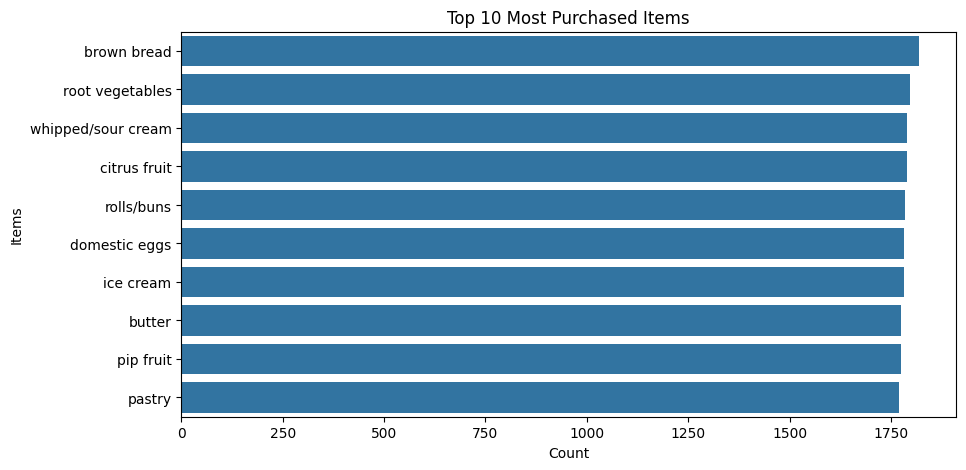

In [55]:
item_count = pd.Series(l).value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=item_count.values, y=item_count.index)

plt.title("Top 10 Most Purchased Items")
plt.xlabel("Count")
plt.ylabel("Items")

plt.show()

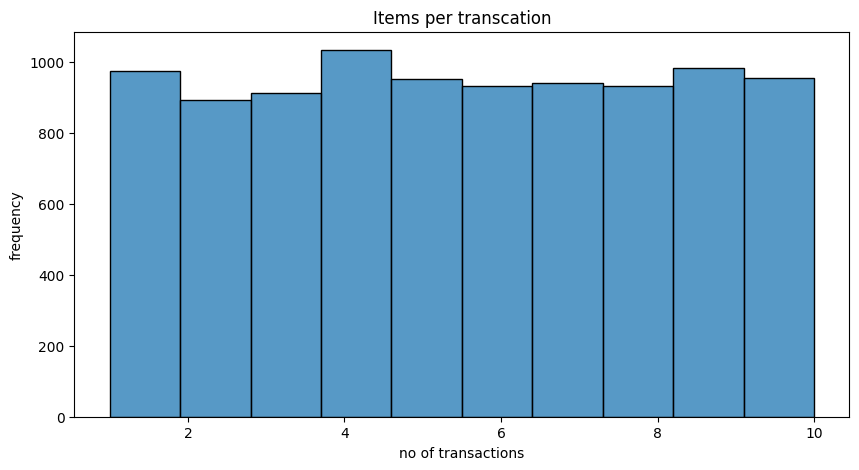

In [58]:
transaction_length = [len(i) for i in market]
plt.figure(figsize=(10,5))
sns.histplot(transaction_length,bins=10)
plt.title("Items per transcation")
plt.xlabel("no of transactions")
plt.ylabel("frequency")

plt.show()

In [27]:
p = collections.Counter(l)

In [33]:
d = {"Item_names":p.keys(),"values":p.values()}

In [34]:
pd.DataFrame(d).sort_values(by=["values"],ascending=False)

,Item_names,values
19,brown bread,1820
25,root vegetables,1796
22,citrus fruit,1790
11,whipped/sour cream,1790
17,rolls/buns,1784
3,domestic eggs,1783
23,ice cream,1782
20,butter,1775
10,pip fruit,1774
27,pastry,1769


In [36]:
tr = TransactionEncoder()

In [37]:
tr.fit(market)

TransactionEncoder()

In [39]:
df1 = pd.DataFrame(tr.transform(market),columns=tr.columns_)

In [62]:
pd.set_option("display.max_rows", None)

In [68]:
freq_items=fpgrowth(df1,min_support=0.02,use_colnames=True,max_len=3).sort_values(by="support", ascending=False)

In [69]:
from mlxtend.frequent_patterns import association_rules

In [77]:
rules=association_rules(freq_items,metric="confidence",min_threshold=0.03)

In [78]:
rules.sort_values(by="confidence", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({shopping bags}),frozenset({brown bread}),0.182947,0.191579,0.044842,0.245109,1.279417,1.0,0.009793,1.070911,0.267295,0.136015,0.066216,0.239588
5,frozenset({ice cream}),frozenset({root vegetables}),0.187579,0.189053,0.044421,0.236813,1.252628,1.0,0.008959,1.062580,0.248243,0.133714,0.058894,0.235890
3,frozenset({whipped/sour cream}),frozenset({brown bread}),0.188421,0.191579,0.044526,0.236313,1.233501,1.0,0.008429,1.058576,0.233248,0.132727,0.055335,0.234365
44,frozenset({other vegetables}),frozenset({brown bread}),0.175684,0.191579,0.041368,0.235470,1.229103,1.0,0.007711,1.057410,0.226126,0.126938,0.054293,0.225702
4,frozenset({root vegetables}),frozenset({ice cream}),0.189053,0.187579,0.044421,0.234967,1.252628,1.0,0.008959,1.061942,0.248695,0.133714,0.058329,0.235890
1,frozenset({brown bread}),frozenset({shopping bags}),0.191579,0.182947,0.044842,0.234066,1.279417,1.0,0.009793,1.066740,0.270149,0.136015,0.062565,0.239588
2,frozenset({brown bread}),frozenset({whipped/sour cream}),0.191579,0.188421,0.044526,0.232418,1.233501,1.0,0.008429,1.057318,0.234160,0.132727,0.054211,0.234365
13,frozenset({shopping bags}),frozenset({pip fruit}),0.182947,0.186737,0.042421,0.231876,1.241725,1.0,0.008258,1.058765,0.238257,0.129624,0.055503,0.229523
18,frozenset({detergent}),frozenset({butter}),0.182105,0.186842,0.042211,0.231792,1.240576,1.0,0.008186,1.058513,0.237100,0.129188,0.055278,0.228854
28,frozenset({margarine}),frozenset({shopping bags}),0.181474,0.182947,0.042000,0.231439,1.265055,1.0,0.008800,1.063093,0.255973,0.130264,0.059349,0.230506


In [83]:
strong_rules = rules[(rules["confidence"] >= 0.2) & (rules["lift"] > 1)]

strong_rules.sort_values(by="confidence", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({shopping bags}),frozenset({brown bread}),0.182947,0.191579,0.044842,0.245109,1.279417,1.0,0.009793,1.070911,0.267295,0.136015,0.066216,0.239588
5,frozenset({ice cream}),frozenset({root vegetables}),0.187579,0.189053,0.044421,0.236813,1.252628,1.0,0.008959,1.062580,0.248243,0.133714,0.058894,0.235890
3,frozenset({whipped/sour cream}),frozenset({brown bread}),0.188421,0.191579,0.044526,0.236313,1.233501,1.0,0.008429,1.058576,0.233248,0.132727,0.055335,0.234365
44,frozenset({other vegetables}),frozenset({brown bread}),0.175684,0.191579,0.041368,0.235470,1.229103,1.0,0.007711,1.057410,0.226126,0.126938,0.054293,0.225702
4,frozenset({root vegetables}),frozenset({ice cream}),0.189053,0.187579,0.044421,0.234967,1.252628,1.0,0.008959,1.061942,0.248695,0.133714,0.058329,0.235890
1,frozenset({brown bread}),frozenset({shopping bags}),0.191579,0.182947,0.044842,0.234066,1.279417,1.0,0.009793,1.066740,0.270149,0.136015,0.062565,0.239588
2,frozenset({brown bread}),frozenset({whipped/sour cream}),0.191579,0.188421,0.044526,0.232418,1.233501,1.0,0.008429,1.057318,0.234160,0.132727,0.054211,0.234365
13,frozenset({shopping bags}),frozenset({pip fruit}),0.182947,0.186737,0.042421,0.231876,1.241725,1.0,0.008258,1.058765,0.238257,0.129624,0.055503,0.229523
18,frozenset({detergent}),frozenset({butter}),0.182105,0.186842,0.042211,0.231792,1.240576,1.0,0.008186,1.058513,0.237100,0.129188,0.055278,0.228854
28,frozenset({margarine}),frozenset({shopping bags}),0.181474,0.182947,0.042000,0.231439,1.265055,1.0,0.008800,1.063093,0.255973,0.130264,0.059349,0.230506


<Axes: xlabel='support', ylabel='confidence'>

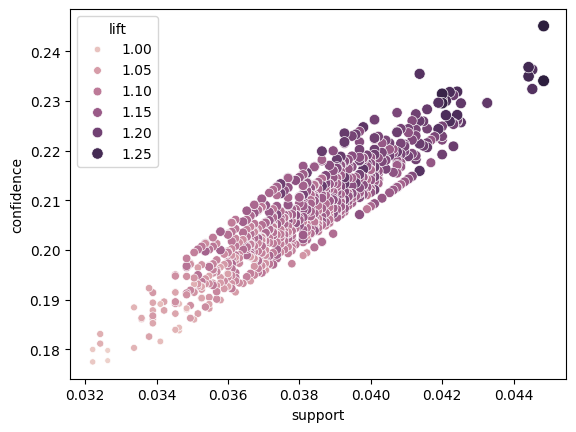

In [84]:
sns.scatterplot(x=rules["support"],
                y=rules["confidence"],
                size=rules["lift"],
                hue =rules["lift"]
               )

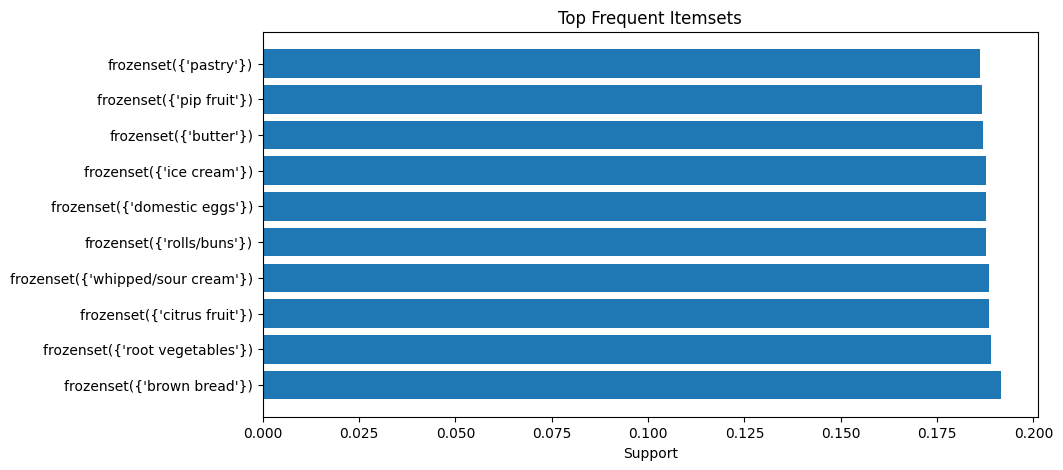

In [85]:
top_items = freq_items.sort_values("support", ascending=False).head(10)
plt.figure(figsize=(10,5))

plt.barh(top_items["itemsets"].astype(str), top_items["support"])

plt.xlabel("Support")
plt.title("Top Frequent Itemsets")

plt.show()

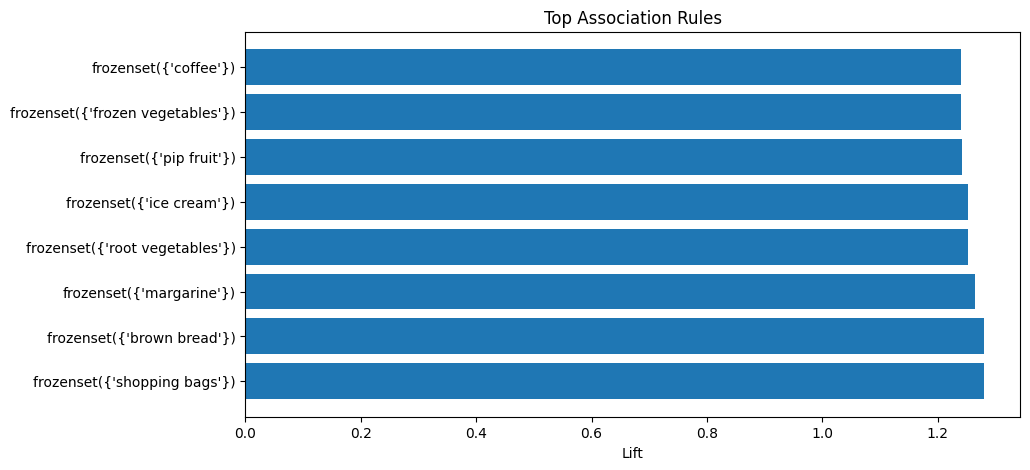

In [86]:
top_rules = rules.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.barh(top_rules["antecedents"].astype(str), top_rules["lift"])

plt.xlabel("Lift")
plt.title("Top Association Rules")

plt.show()

### recommendation

In [90]:
def recommend(product):
    rec = rules[rules["antecedents"].apply(lambda x: product in x)]
    rec = rec.sort_values("confidence", ascending=False)
    return rec["consequents"].head(5)

In [91]:
recommend("whole milk")

72      frozenset({rolls/buns})
86       frozenset({ice cream})
100         frozenset({butter})
105    frozenset({brown bread})
183           frozenset({pork})
Name: consequents, dtype: object